# 📱 Mobile App Store Clustering

## 🎯 Project Objective

The objective of this project is to segment Google Play Store applications into meaningful groups using unsupervised machine learning techniques. By analyzing app characteristics such as category, rating, installs, price, size, and content rating, the project aims to discover hidden patterns without using predefined labels.

The project applies data preprocessing, feature engineering, one-hot encoding, feature scaling, K-Means Clustering, and Agglomerative Clustering. The optimal number of clusters is determined using the Elbow Method and Silhouette Score, while PCA is used for two-dimensional visualization of the clustering results.

Finally, the identified clusters are analyzed and interpreted to generate business insights that can help understand different types of mobile applications and their market segments.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage
from kneed import KneeLocator



# Load Dataset

**Note:** The original dataset contains over 2 million Google Play Store applications. A representative sample of 10,000 applications was used in this project to reduce computational cost while preserving the overall data distribution.

In [2]:
df = pd.read_csv('Google-Playstore.csv')
df.head()

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,...,Developer Website,Developer Email,Released,Last Updated,Content Rating,Privacy Policy,Ad Supported,In App Purchases,Editors Choice,Scraped Time
0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10+,10.0,15,True,0.0,...,https://beniyizibyose.tk/#/,jean21101999@gmail.com,"Feb 26, 2020","Feb 26, 2020",Everyone,https://beniyizibyose.tk/projects/,False,False,False,2021-06-15 20:19:35
1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,"5,000+",5000.0,7662,True,0.0,...,https://webserveis.netlify.app/,webserveis@gmail.com,"May 21, 2020","May 06, 2021",Everyone,https://dev4phones.wordpress.com/licencia-de-uso/,True,False,False,2021-06-15 20:19:35
2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50+,50.0,58,True,0.0,...,NaN,vnacrewit@gmail.com,"Aug 9, 2019","Aug 19, 2019",Everyone,https://www.vietnamairlines.com/vn/en/terms-an...,False,False,False,2021-06-15 20:19:35
3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10+,10.0,19,True,0.0,...,http://www.climatesmarttech.com/,climatesmarttech2@gmail.com,"Sep 10, 2018","Oct 13, 2018",Everyone,NaN,True,False,False,2021-06-15 20:19:35
4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100+,100.0,478,True,0.0,...,http://www.horodyski.com.pl,rmilekhorodyski@gmail.com,"Feb 21, 2020","Nov 12, 2018",Everyone,http://www.horodyski.com.pl,False,False,False,2021-06-15 20:19:35


# Dataset Overview

In [3]:
df.shape

(2312944, 24)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2312944 entries, 0 to 2312943
Data columns (total 24 columns):
 #   Column             Dtype  
---  ------             -----  
 0   App Name           object 
 1   App Id             object 
 2   Category           object 
 3   Rating             float64
 4   Rating Count       float64
 5   Installs           object 
 6   Minimum Installs   float64
 7   Maximum Installs   int64  
 8   Free               bool   
 9   Price              float64
 10  Currency           object 
 11  Size               object 
 12  Minimum Android    object 
 13  Developer Id       object 
 14  Developer Website  object 
 15  Developer Email    object 
 16  Released           object 
 17  Last Updated       object 
 18  Content Rating     object 
 19  Privacy Policy     object 
 20  Ad Supported       bool   
 21  In App Purchases   bool   
 22  Editors Choice     bool   
 23  Scraped Time       object 
dtypes: bool(4), float64(4), int64(1), object(15)
memor

In [5]:
df.describe()

,Rating,Rating Count,Minimum Installs,Maximum Installs,Price
count,2.290061e+06,2.290061e+06,2.312837e+06,2.312944e+06,2.312944e+06
mean,2.203152e+00,2.864839e+03,1.834452e+05,3.202017e+05,1.034992e-01
std,2.106223e+00,2.121626e+05,1.513144e+07,2.355495e+07,2.633127e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,5.000000e+01,8.400000e+01,0.000000e+00
50%,2.900000e+00,6.000000e+00,5.000000e+02,6.950000e+02,0.000000e+00
75%,4.300000e+00,4.200000e+01,5.000000e+03,7.354000e+03,0.000000e+00
max,5.000000e+00,1.385576e+08,1.000000e+10,1.205763e+10,4.000000e+02


In [6]:
df.isnull().sum()

App Name                  5
App Id                    0
Category                  0
Rating                22883
Rating Count          22883
Installs                107
Minimum Installs        107
Maximum Installs          0
Free                      0
Price                     0
Currency                135
Size                    196
Minimum Android        6530
Developer Id             33
Developer Website    760835
Developer Email          31
Released              71053
Last Updated              0
Content Rating            0
Privacy Policy       420953
Ad Supported              0
In App Purchases          0
Editors Choice            0
Scraped Time              0
dtype: int64

## Data Cleaning

In [7]:
df = df[['App Name','Category','Rating','Free','Price','Installs','Size','Content Rating','Ad Supported','In App Purchases']]

## Sampling

The original dataset is large, so a random sample of 10,000 applications is used to reduce computational cost while preserving the overall distribution of the data.

In [8]:
df = df.sample(10000,random_state=42)
df = df.drop_duplicates()
df = df.dropna()

In [10]:
df['Installs'] = (df['Installs'].str.replace(",","").str.replace('+','', ).astype(int))

In [11]:
def convert_szie(size):
    if pd.isna(size):
        return None
    size = str(size).replace(',', '')
    if size.endswith('G'):
        return float(size[:-1])*1024
    elif size.endswith('M'):
        return float(size[:-1])
    elif size.endswith('k'):
        return float(size[:-1])/1024
    else:
        return None

df['Size(MB)'] = df['Size'].apply(convert_szie)
df = df.drop('Size',axis=1)
df = df.dropna()

In [12]:
df.isnull().sum()

App Name            0
Category            0
Rating              0
Free                0
Price               0
Installs            0
Content Rating      0
Ad Supported        0
In App Purchases    0
Size(MB)            0
dtype: int64

In [13]:
df.head()

,App Name,Category,Rating,Free,Price,Installs,Content Rating,Ad Supported,In App Purchases,Size(MB)
1843548,"St. Thomas Knanaya Catholic Church, Mankuzhy",Communication,0.0,True,0.00,1,Everyone,False,False,14.0
421026,Gaple Live,Card,3.3,True,0.00,5000,Everyone,False,True,47.0
2036441,Handwriting Improvements,Education,0.0,True,0.00,5,Everyone,True,False,6.8
1525791,AudioBrain Business,Business,4.8,False,0.99,1000,Everyone,False,False,6.6
1748509,Hungary Tourist Map Offline,Maps & Navigation,0.0,True,0.00,100,Everyone 10+,True,False,3.4


## Feature Engineering

In [14]:
alpha = pd.get_dummies(df, columns=['Category','Content Rating'],drop_first=True)

In [15]:
alpha.columns

Index(['App Name', 'Rating', 'Free', 'Price', 'Installs', 'Ad Supported',
       'In App Purchases', 'Size(MB)', 'Category_Adventure', 'Category_Arcade',
       'Category_Art & Design', 'Category_Auto & Vehicles', 'Category_Beauty',
       'Category_Board', 'Category_Books & Reference', 'Category_Business',
       'Category_Card', 'Category_Casino', 'Category_Casual',
       'Category_Comics', 'Category_Communication', 'Category_Dating',
       'Category_Education', 'Category_Educational', 'Category_Entertainment',
       'Category_Events', 'Category_Finance', 'Category_Food & Drink',
       'Category_Health & Fitness', 'Category_House & Home',
       'Category_Libraries & Demo', 'Category_Lifestyle',
       'Category_Maps & Navigation', 'Category_Medical', 'Category_Music',
       'Category_Music & Audio', 'Category_News & Magazines',
       'Category_Parenting', 'Category_Personalization',
       'Category_Photography', 'Category_Productivity', 'Category_Puzzle',
       'Category_Rac

In [16]:
bool_column = alpha.select_dtypes(include='bool').columns

for col in bool_column:
    alpha[col] = alpha[col].astype(int)
    

## Feature Selection

In [17]:
feature = ['Rating','Free','Price','Installs','Size(MB)','Ad Supported','In App Purchases']

category_cols = [col for col in alpha.columns if col.startswith('Category_')]
content_cols = [
    col for col in alpha.columns
    if col.startswith('Content Rating_')
]

final_features = feature + category_cols + content_cols

In [18]:
X = alpha[final_features]

## Why StandardScaler?

 K-Means uses Euclidean distance. Standardization ensures that features contribute equally.

In [19]:
ss = StandardScaler()
X_scale = ss.fit_transform(X)

## Elbow Method

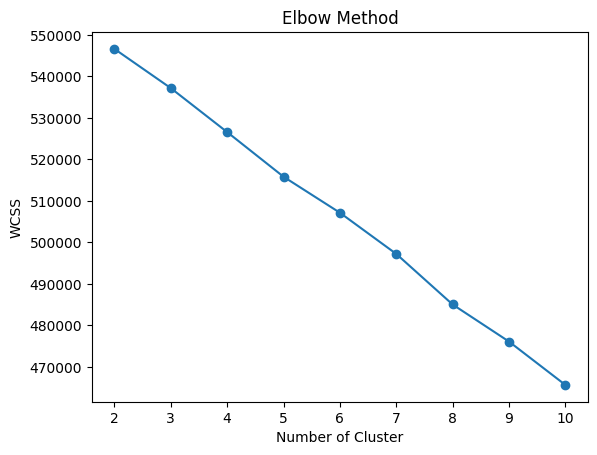

In [20]:
wcss = []
for k in range(2,11):  
    kmean = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmean.fit_predict(X_scale)
    wcss.append(kmean.inertia_)

plt.plot(range(2,11),wcss,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Cluster')
plt.ylabel('WCSS')
plt.savefig("images/elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
knee = KneeLocator(range(2,11),wcss, curve='convex', direction='decreasing')
print(knee.elbow)

2


## Silhouette Score

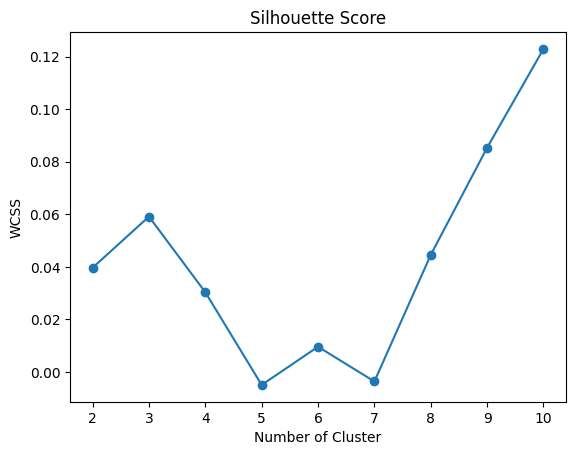

In [22]:
silhouette_scores = []
for k in range(2,11):  
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = kmeans.fit_predict(X_scale)

    score = silhouette_score(X_scale, labels)
    silhouette_scores.append(score)

plt.plot(range(2,11),silhouette_scores,marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of Cluster')
plt.ylabel('WCSS')
plt.savefig("images/silhouette_score.png", dpi=300, bbox_inches="tight")
plt.show()
kmean_scores = max(silhouette_scores)

## Final K-Means Model

In [23]:
kmean = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster = kmean.fit_predict(X_scale)
X['Cluster'] = cluster


In [24]:
X['Cluster'].value_counts()

Cluster
1    5274
2    3029
0    1344
Name: count, dtype: int64

## Cluster Analysis

In [25]:
cluster_summary = X.groupby('Cluster')[
    ['Rating',
    'Installs',
    'Price',
    'Size(MB)']
].mean()

cluster_summary['Count'] = X.groupby('Cluster').size()
cluster_summary.round(2)

,Rating,Installs,Price,Size(MB),Count
Cluster,,,,,
0,2.39,88485.29,0.33,20.86,1344
1,1.92,26394.56,0.10,18.43,5274
2,2.61,185172.76,0.14,21.76,3029


In [26]:
for cluster in X['Cluster'].unique():

    print(f"\nCluster {cluster}")

    print(
        df.loc[X['Cluster'] == cluster, 'Category']
        .value_counts()
        .head(5)
    )


Cluster 1
Category
Education       935
Business        569
Tools           549
Lifestyle       473
Productivity    341
Name: count, dtype: int64

Cluster 2
Category
Music & Audio        523
Books & Reference    457
Personalization      348
Arcade               209
Puzzle               191
Name: count, dtype: int64

Cluster 0
Category
Entertainment      575
Social             176
Music & Audio      138
Lifestyle           38
Personalization     34
Name: count, dtype: int64


# Business Insights

### Cluster 0 – Entertainment & Social Apps
- Largest user segment
- Dominated by entertainment and social categories
- Moderate installs and ratings

### Cluster 1 – Productivity & Education Apps
- Highest average installs and ratings
- Includes education, business, productivity, and finance apps

### Cluster 2 – Content & Personalization Apps
- Smaller niche segment
- Includes music, books, photography, and personalization apps

In [27]:
cluster_names = {
    0: 'Entertainment & Social Apps',
    1: 'Productivity & Education Apps',
    2: 'Content & Personalization Apps'
}

X['Cluster_Name'] = X['Cluster'].map(cluster_names)

## PCA Visualization

In [28]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scale)
centers_pca = pca.transform(kmean.cluster_centers_)
X['PCA1'] = pca_data[:,0]
X['PCA2'] = pca_data[:,1]


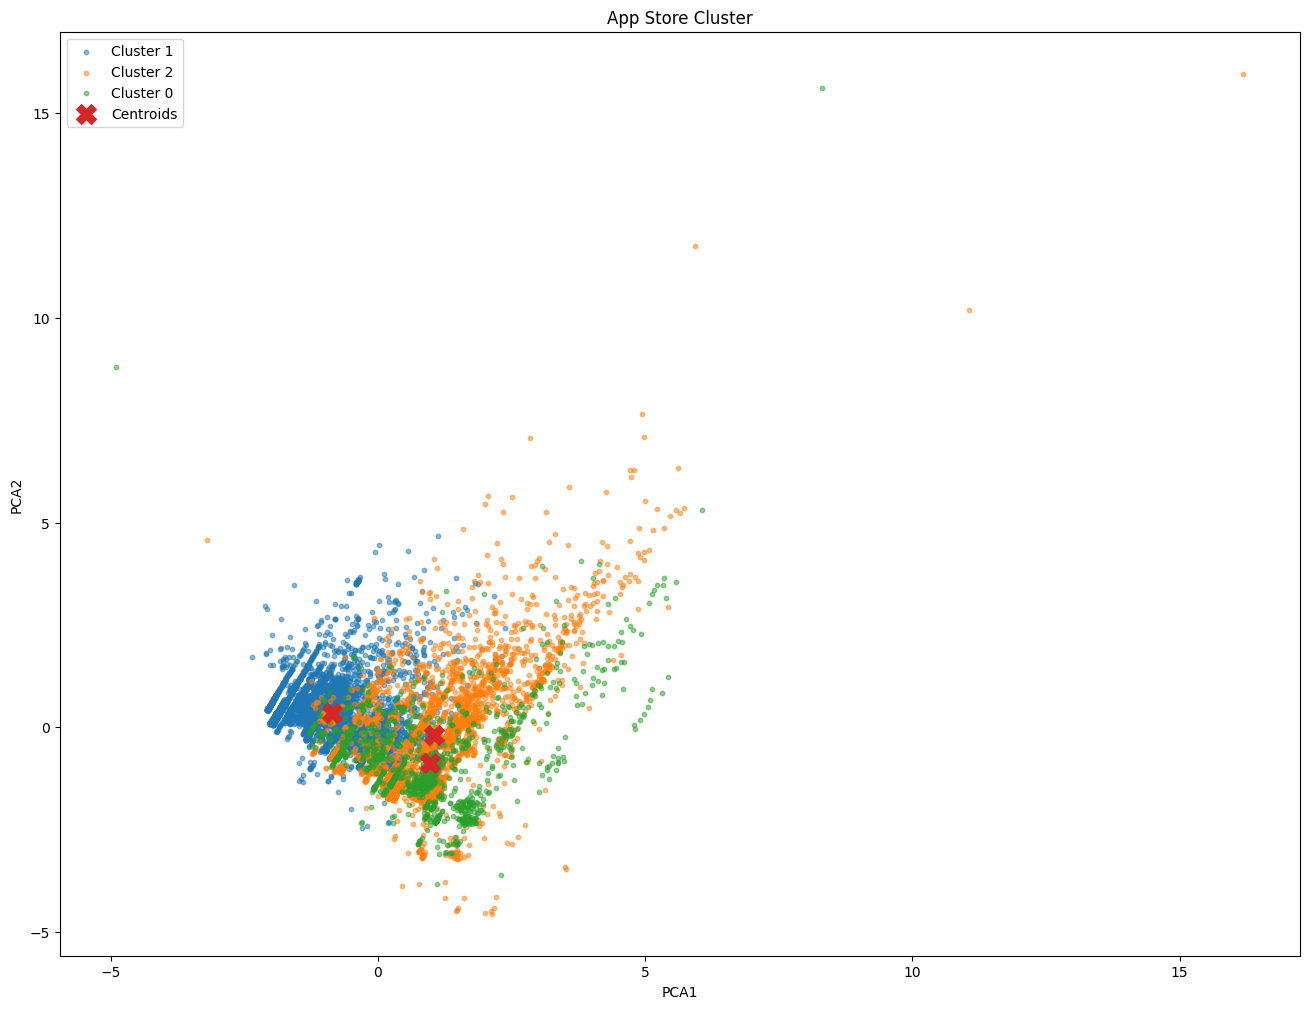

0.05666982302952994


In [29]:
plt.figure(figsize=(16,12))

for cluster in X['Cluster'].unique():
    subset = X[X['Cluster']== cluster] 
    plt.scatter(subset['PCA1'], subset['PCA2'],alpha=0.5,s=10, label = f"Cluster {cluster}")
plt.scatter(
    centers_pca[:,0],
    centers_pca[:,1],
    marker='X',
    s=200,
    label='Centroids'
)
plt.title('App Store Cluster')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend()
plt.savefig('images/PCA_Cluster_Plot.png', dpi=300, bbox_inches="tight" )
plt.show()

print(pca.explained_variance_ratio_.sum())

# Hierarchical Clustering

Agglomerative Clustering is applied to compare its performance with K-Means.

Unlike K-Means, which partitions data around centroids, Agglomerative Clustering builds a hierarchy by iteratively merging the closest clusters.

The resulting clusters are evaluated using the Silhouette Score and visually compared with the K-Means solution.

In [30]:
sample = X_scale[:1000]

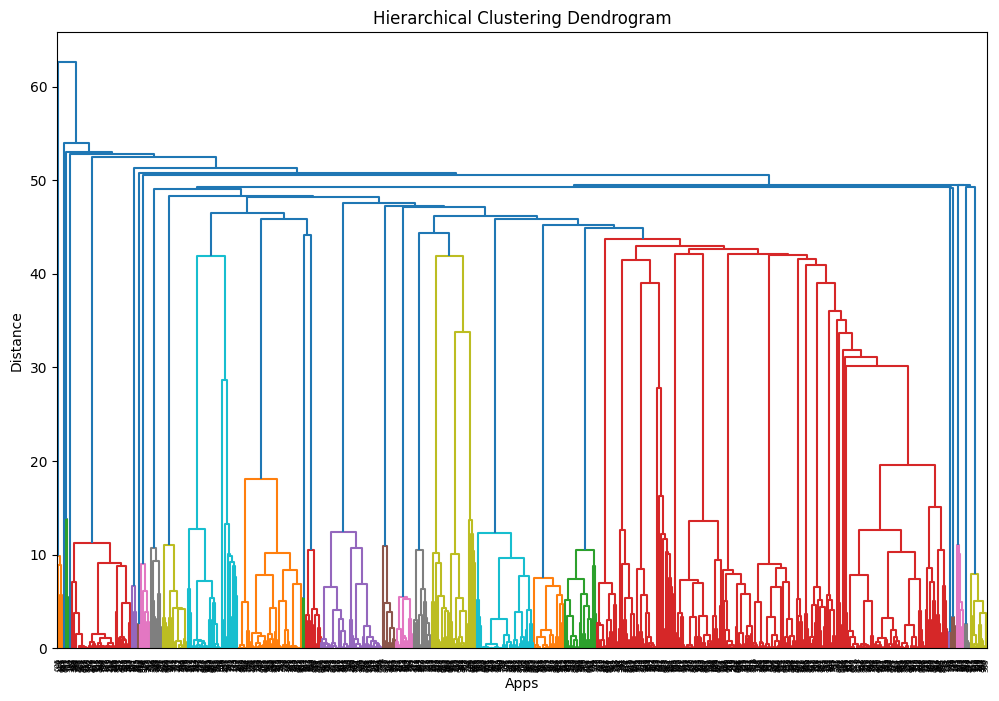

In [31]:
linked = linkage(
    sample,
    method='ward'
)

plt.figure(figsize=(12,8))

dendrogram(linked)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Apps')
plt.ylabel('Distance')
plt.savefig('images/dendrogram.png', dpi=300, bbox_inches="tight" )
plt.show()

In [32]:
agg = AgglomerativeClustering(n_clusters=3)
labels = agg.fit_predict(X_scale)

agg_score = silhouette_score(X_scale, labels)

print(f"Silhouette Score: {agg_score:.3f}")



Silhouette Score: 0.031


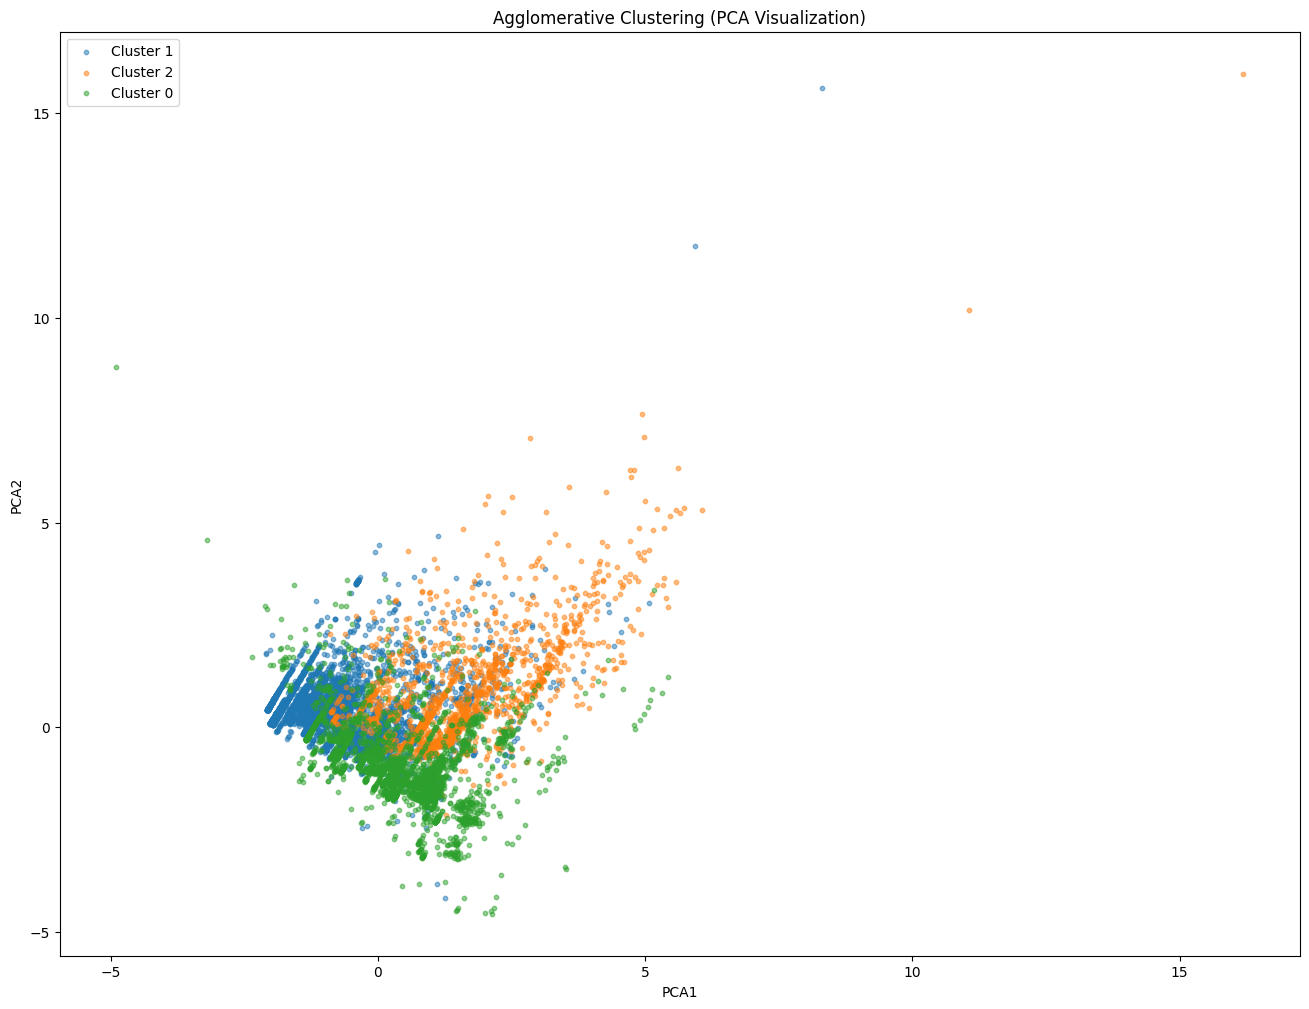

In [33]:
X['Agg_Cluster'] = labels
plt.figure(figsize=(16,12))

for cluster in X['Agg_Cluster'].unique():
    subset = X[X['Agg_Cluster']== cluster] 
    plt.scatter(subset['PCA1'], subset['PCA2'],alpha=0.5,s=10, label = f"Cluster {cluster}")

plt.title("Agglomerative Clustering (PCA Visualization)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.savefig('images/Agglomerative_Clustering_Plot.png', dpi=300 ,bbox_inches='tight')
plt.legend()
plt.show()

# Final Comparison

In [34]:
result = []
result.append({
    'Algorithm': 'K-Means',
    'Silhouette Score': kmean_scores,
    'Selected':'✅'
})
result.append({
    'Algorithm': 'AgglomerativeClustering',
    'Silhouette Score': agg_score,
    'Selected':'❌'
})

results = pd.DataFrame(result)
results

,Algorithm,Silhouette Score,Selected
0,K-Means,0.122936,✅
1,AgglomerativeClustering,0.031222,❌


## Final Conclusion

Both clustering algorithms successfully segmented the applications.

K-Means achieved the higher Silhouette Score and produced more compact and well-separated clusters.

Therefore, K-Means was selected as the final clustering model for this project.